# 03 — Signal Backtest

For every historical inversion episode, measure:
- Duration, depth, mean depth
- Lead time to the next recession (or 'no recession' within look-ahead window)
- True positive vs. false positive classification

Then compute aggregate statistics and produce **the key table for the article**.

Signal definitions are fixed **before** analysis — no post-hoc tuning.

**Prereq:** run `01_data_pull.ipynb` first.

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.signal_utils import (
    find_inversion_episodes,
    compute_lead_times,
    aggregate_metrics,
    recession_bands,
    depth_vs_lead_time,
)
from src import viz

sns.set_theme(style='whitegrid', font_scale=1.1)
pd.set_option('display.float_format', '{:.1f}'.format)

## Signal definitions (fixed — document before running)

| Parameter | Value | Rationale |
|---|---|---|
| Inversion threshold | spread < 0 | Standard definition |
| Min episode duration | 3 months | Excludes brief noise dips |
| Min separation | 12 months | Separates distinct rate cycles |
| Look-ahead window | 24 months | Standard used in most academic literature; we also test 36 months |

These are **not tuned to improve hit rate**. They are set a priori based on the spec.

In [2]:
df = pd.read_csv('../data/raw/merged_monthly.csv', index_col=0, parse_dates=True)
rec = df['USREC'].dropna()
rec_bands = recession_bands(rec)

LOOKAHEAD_PRIMARY = 24
LOOKAHEAD_EXTENDED = 36

## 2s10s Backtest

In [3]:
episodes_2s10s = find_inversion_episodes(
    df['SPREAD_2S10S'].dropna(),
    min_duration_months=3,
    min_separation_months=12,
)

bt_2s10s = compute_lead_times(episodes_2s10s, rec, max_lead_months=LOOKAHEAD_PRIMARY)

# Format for display
display_cols = [
    'episode_id', 'start', 'end', 'duration_months',
    'max_depth', 'recession_start', 'lead_time_months', 'result', 'ongoing'
]
bt_2s10s_disp = bt_2s10s[display_cols].copy()
bt_2s10s_disp['start'] = pd.to_datetime(bt_2s10s_disp['start']).dt.strftime('%Y-%m')
bt_2s10s_disp['end'] = pd.to_datetime(bt_2s10s_disp['end']).dt.strftime('%Y-%m')
bt_2s10s_disp['recession_start'] = pd.to_datetime(bt_2s10s_disp['recession_start']).dt.strftime('%Y-%m')

print(f'=== 2s10s Backtest (look-ahead: {LOOKAHEAD_PRIMARY} months) ===')
print(bt_2s10s_disp.to_string(index=False))

=== 2s10s Backtest (look-ahead: 24 months) ===
 episode_id   start     end  duration_months  max_depth recession_start  lead_time_months        result  ongoing
          1 1978-09 1982-06               46       -2.1         1980-02              17.0 true positive    False
          2 1989-01 1990-03               15       -0.3         1990-08              19.0 true positive    False
          3 2000-02 2000-12               11       -0.4         2001-04              14.0 true positive    False
          4 2006-02 2007-05               16       -0.1         2008-01              23.0 true positive    False
          5 2022-07 2024-08               26       -0.9             NaN               NaN  no recession    False


## 2s10s Aggregate Metrics

In [4]:
metrics_2s10s = aggregate_metrics(bt_2s10s)
for k, v in metrics_2s10s.items():
    print(f'  {k}: {v}')

  total_episodes: 5
  true_positives: 4
  false_positives: 1
  hit_rate_pct: 80.0
  lead_time_mean: 18.2
  lead_time_median: 18.0
  lead_time_min: 14
  lead_time_max: 23


## 10Y–3M Backtest — Extended (1962–present)

The official `T10Y3M` series only starts 1982. By using `DGS10 - DTB3` we extend back to 1962, picking up inversions before the 1969-70, 1973-75, and 1980 recessions — adding three more test cases to the sample.

**Note on data quality:** Pre-1982 values are computed manually from the component yields (the same methodology FRED uses for `T10Y3M`). The overlap period (1982+) is nearly identical to the official series.

In [5]:
episodes_10y3m_ext = find_inversion_episodes(
    df['SPREAD_10Y3M_EXTENDED'].dropna(),
    min_duration_months=3,
    min_separation_months=12,
)

# Only classify episodes that started before June 2024 as definitive
# (those started before that date have at least 24 months of look-ahead through June 2026)
CUTOFF_DATE = pd.Timestamp('2024-06-30')
episodes_for_bt = episodes_10y3m_ext.copy()

bt_10y3m_ext = compute_lead_times(episodes_for_bt, rec, max_lead_months=LOOKAHEAD_PRIMARY)

# Flag episodes that started after the cutoff — their look-ahead window isn't fully closed yet
bt_10y3m_ext['note'] = bt_10y3m_ext['start'].apply(
    lambda s: 'look-ahead open' if pd.Timestamp(s) > CUTOFF_DATE else ''
)

bt_10y3m_disp = bt_10y3m_ext[display_cols + ['note']].copy()
for col in ['start', 'end', 'recession_start']:
    bt_10y3m_disp[col] = pd.to_datetime(bt_10y3m_disp[col]).dt.strftime('%Y-%m')

print(f'=== 10Y–3M Extended Backtest (1962–present, look-ahead: {LOOKAHEAD_PRIMARY} months) ===')
print(bt_10y3m_disp.to_string(index=False))

# Aggregate on episodes with closed look-ahead windows only
bt_10y3m_closed = bt_10y3m_ext[bt_10y3m_ext['note'] != 'look-ahead open']
metrics_10y3m_ext = aggregate_metrics(bt_10y3m_closed)
print('\nAggregate metrics (episodes with closed 24-month window):')
for k, v in metrics_10y3m_ext.items():
    print(f'  {k}: {v}')

=== 10Y–3M Extended Backtest (1962–present, look-ahead: 24 months) ===
 episode_id   start     end  duration_months  max_depth recession_start  lead_time_months        result  ongoing note
          1 1966-09 1967-01                5       -0.3             NaN               NaN  no recession    False     
          2 1969-01 1970-01               13       -0.3         1970-01              12.0 true positive    False     
          3 1973-06 1974-09               16       -1.3         1973-12               6.0 true positive    False     
          4 1978-12 1981-08               33       -2.7         1980-02              14.0 true positive    False     
          5 1989-06 1989-12                7       -0.2         1990-08              14.0 true positive    False     
          6 2000-07 2001-01                7       -0.7         2001-04               9.0 true positive    False     
          7 2006-08 2007-05               10       -0.5         2008-01              17.0 true positive

## Side-by-side comparison table

In [6]:
# Also compute metrics for the official T10Y3M (1982+) for comparison
episodes_10y3m_official = find_inversion_episodes(
    df['SPREAD_10Y3M'].dropna(),
    min_duration_months=3,
    min_separation_months=12,
)
bt_10y3m = compute_lead_times(episodes_10y3m_official, rec, max_lead_months=LOOKAHEAD_PRIMARY)
bt_10y3m_closed_official = bt_10y3m[bt_10y3m['start'].apply(lambda s: pd.Timestamp(s) <= CUTOFF_DATE)]
metrics_10y3m = aggregate_metrics(bt_10y3m_closed_official)

In [7]:
comparison = pd.DataFrame({
    '2s10s (1976+)':        metrics_2s10s,
    '10Y–3M (1982+)':       metrics_10y3m,
    '10Y–3M Extended (1962+)': metrics_10y3m_ext,
}).T
print('\n=== Aggregate Comparison ===')
print(comparison.to_string())


=== Aggregate Comparison ===
                         total_episodes  true_positives  false_positives  hit_rate_pct  lead_time_mean  lead_time_median  lead_time_min  lead_time_max
2s10s (1976+)                       5.0             4.0              1.0          80.0            18.2              18.0           14.0           23.0
10Y–3M (1982+)                      9.0             7.0              2.0          77.8            11.7              12.0            6.0           17.0
10Y–3M Extended (1962+)             9.0             7.0              2.0          77.8            11.7              12.0            6.0           17.0


## Sensitivity: 36-month look-ahead

Does extending the window reclassify any 'no recession' episodes as true positives?

In [8]:
bt_2s10s_36 = compute_lead_times(episodes_2s10s, rec, max_lead_months=LOOKAHEAD_EXTENDED)
metrics_36 = aggregate_metrics(bt_2s10s_36)

print(f'=== 2s10s with {LOOKAHEAD_EXTENDED}-month look-ahead ===')
for k, v in metrics_36.items():
    print(f'  {k}: {v}')

# Highlight any episodes that changed classification
compare_windows = bt_2s10s[['episode_id','start','result']].rename(columns={'result': 'result_24m'}).merge(
    bt_2s10s_36[['episode_id','result']].rename(columns={'result': 'result_36m'}),
    on='episode_id'
)
changed = compare_windows[compare_windows['result_24m'] != compare_windows['result_36m']]
if len(changed):
    print('\nEpisodes reclassified by extending window:')
    print(changed.to_string(index=False))
else:
    print('\nNo episodes changed classification.')

=== 2s10s with 36-month look-ahead ===
  total_episodes: 5
  true_positives: 4
  false_positives: 1
  hit_rate_pct: 80.0
  lead_time_mean: 18.2
  lead_time_median: 18.0
  lead_time_min: 14
  lead_time_max: 23

No episodes changed classification.


## COVID recession flag

The 2020 COVID recession was an external shock, not a business cycle event. The spec says to show both versions (including and excluding it).

In [9]:
# Identify which episodes have a recession_start in 2020
bt_2s10s['recession_start_dt'] = pd.to_datetime(bt_2s10s['recession_start'])
covid_mask = bt_2s10s['recession_start_dt'].dt.year == 2020

print('Episodes attributed to COVID recession (2020):')
print(bt_2s10s[covid_mask][['episode_id','start','recession_start','lead_time_months']].to_string(index=False))

# Metrics excluding COVID
bt_no_covid = bt_2s10s[~covid_mask].copy()
# If the episode would otherwise be a false positive, mark it so
bt_no_covid_recoded = bt_2s10s.copy()
bt_no_covid_recoded.loc[covid_mask, 'result'] = 'covid_excluded'

metrics_excl_covid = aggregate_metrics(bt_no_covid)
print('\nMetrics EXCLUDING COVID recession:')
for k, v in metrics_excl_covid.items():
    print(f'  {k}: {v}')

Episodes attributed to COVID recession (2020):
Empty DataFrame
Columns: [episode_id, start, recession_start, lead_time_months]
Index: []

Metrics EXCLUDING COVID recession:
  total_episodes: 5
  true_positives: 4
  false_positives: 1
  hit_rate_pct: 80.0
  lead_time_mean: 18.2
  lead_time_median: 18.0
  lead_time_min: 14
  lead_time_max: 23


## Does inversion depth predict lead time?

Pearson correlation (depth vs. lead time): r=0.333, p=0.667
(Negative correlation would mean deeper inversion → shorter lead time)


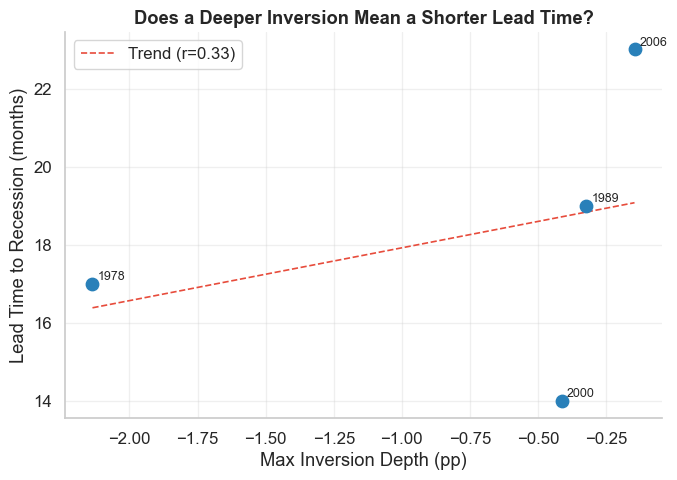

In [10]:
depth_df = depth_vs_lead_time(bt_2s10s)
if len(depth_df) >= 3:
    from scipy import stats
    r, p = stats.pearsonr(depth_df['max_depth'], depth_df['lead_time_months'])
    print(f'Pearson correlation (depth vs. lead time): r={r:.3f}, p={p:.3f}')
    print('(Negative correlation would mean deeper inversion → shorter lead time)')

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.scatter(depth_df['max_depth'], depth_df['lead_time_months'],
               color='#2980b9', s=80, zorder=3)
    for _, row in depth_df.iterrows():
        ax.annotate(pd.Timestamp(row['start']).strftime('%Y'),
                    (row['max_depth'], row['lead_time_months']),
                    xytext=(4, 3), textcoords='offset points', fontsize=9)
    m, b = np.polyfit(depth_df['max_depth'], depth_df['lead_time_months'], 1)
    xs = np.linspace(depth_df['max_depth'].min(), depth_df['max_depth'].max(), 50)
    ax.plot(xs, m * xs + b, color='#e74c3c', linewidth=1.2, linestyle='--',
            label=f'Trend (r={r:.2f})')
    ax.set_xlabel('Max Inversion Depth (pp)')
    ax.set_ylabel('Lead Time to Recession (months)')
    ax.set_title('Does a Deeper Inversion Mean a Shorter Lead Time?', fontweight='bold')
    ax.legend()
    ax.grid(alpha=0.3)
    sns.despine(ax=ax)
    plt.tight_layout()
    fig.savefig('../reports/figures/06_depth_vs_leadtime.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Not enough true positive episodes for correlation analysis.')

## Lead time distribution chart

  Saved: C:\Users\frase\OneDrive\Documents\FRED\yield-curve-recession\notebooks\..\reports\figures\07_lead_time_distribution.png


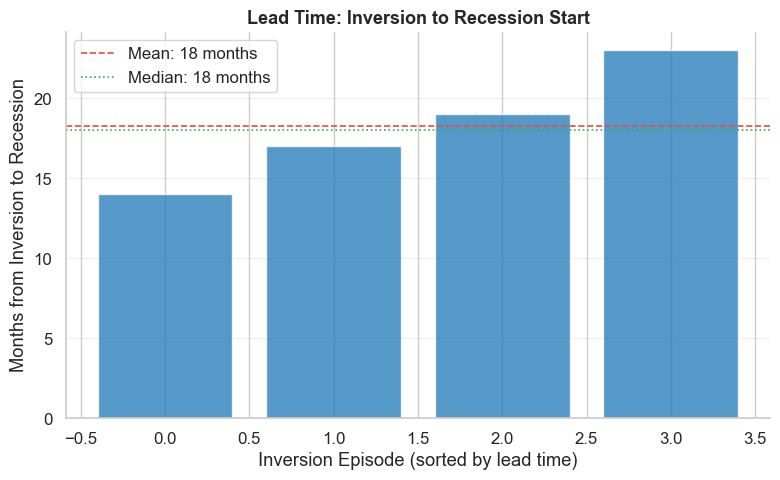

In [11]:
viz.plot_lead_time_distribution(bt_2s10s, save_path='07_lead_time_distribution.png')
plt.show()

## Save backtest tables

Backtest tables saved.


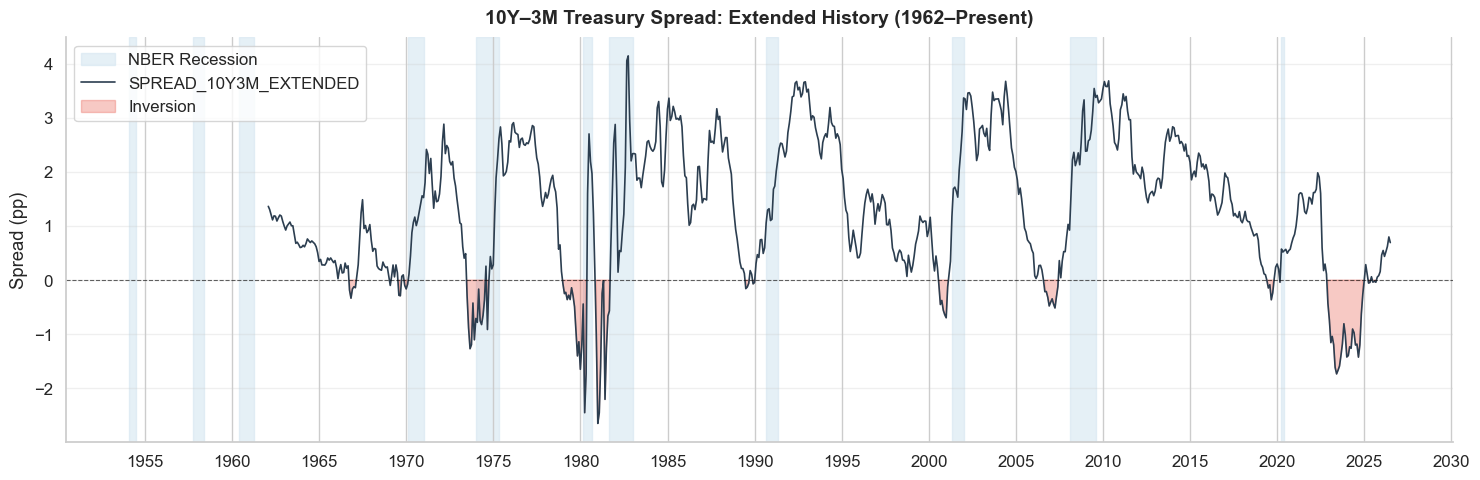

Extended history chart saved.


In [12]:
bt_2s10s.to_csv('../data/raw/backtest_2s10s.csv', index=False)
bt_10y3m.to_csv('../data/raw/backtest_10y3m.csv', index=False)
bt_10y3m_ext.to_csv('../data/raw/backtest_10y3m_extended.csv', index=False)
print('Backtest tables saved.')

# Chart: extended 10Y-3M spread over full history
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

fig, ax = plt.subplots(figsize=(15, 5))
spread_ext = df['SPREAD_10Y3M_EXTENDED'].dropna()
from src.signal_utils import recession_bands as _rb
rec_bands_for_chart = _rb(df['USREC'].dropna())
viz.plot_spread_history(
    spread_ext,
    rec_bands_for_chart,
    title='10Y–3M Treasury Spread: Extended History (1962–Present)',
    ylabel='Spread (pp)',
    ax=ax,
)
plt.tight_layout()
fig.savefig('../reports/figures/13_10y3m_extended_history.png', dpi=150, bbox_inches='tight')
plt.show()
print('Extended history chart saved.')

## Key findings (for article)

Fill this cell in after running the analysis above. Template:

- **Total 2s10s episodes (1976–present):** _N_
- **Hit rate (24-month window):** _X%_
- **False positives:** _N_
- **Lead time range:** _min_ to _max_ months
- **Median lead time:** _N_ months
- **With 36-month window:** _X%_ hit rate
- **Excluding COVID:** _X%_ hit rate